# RIPRA Synthetic SHWFS Data Generator

Generates physically accurate synthetic Shack-Hartmann wavefront sensor
data for the RIPRA AO pipeline. All parameters exactly match the C code's
expectations (recon.c, centroid.c, io.c).

**Outputs:**
- `data_raw/sh_flat.raw` – reference flat frame (double, row-major)
- `data_raw/img.raw` – aberrated frame with known Zernike coefficients
- `ml_checkpoints/local/best_mlp.pt` – trained MLP model
- `ml_checkpoints/local/best_cnn.pt` – trained CNN model
- `data_ai/dataset.npz` – ML training dataset

Run this once on Kaggle, download the outputs, and commit to the repo.



## 1. Setup — Install dependencies & configure paths



In [1]:
import os, sys, math, json, shutil
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# Install additional deps if on Kaggle
try:
    import torch
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', 'torch'])
    import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Determine working directory
if os.path.exists('/kaggle'):
    BASE = '/kaggle/working'
    # If on Kaggle and the repo is missing, clone the repository
    if not os.path.exists(os.path.join(BASE, 'rippra')):
        print("Clean Kaggle environment detected. Cloning the repository...")
        import subprocess
        subprocess.run(['git', 'clone', 'https://github.com/PxA-Labs/Project-RIPRA.git', '/tmp/repo'], check=True)
        # Move files from /tmp/repo to /kaggle/working
        import shutil
        for item in os.listdir('/tmp/repo'):
            s = os.path.join('/tmp/repo', item)
            d = os.path.join(BASE, item)
            if os.path.isdir(s):
                if os.path.exists(d):
                    shutil.rmtree(d)
                shutil.copytree(s, d)
            else:
                shutil.copy2(s, d)
        shutil.rmtree('/tmp/repo')
        print("Repository cloned successfully into /kaggle/working!")
else:
    BASE = os.path.abspath(os.path.join(os.getcwd(), '..'))

os.chdir(BASE)
print(f"Working directory: {BASE}")
os.makedirs('data_raw', exist_ok=True)
os.makedirs('ml_checkpoints/local', exist_ok=True)
os.makedirs('data_ai', exist_ok=True)
os.makedirs('visualizations', exist_ok=True)




Clean Kaggle environment detected. Cloning the repository...


Cloning into '/tmp/repo'...


Repository cloned successfully into /kaggle/working!
Working directory: /kaggle/working


## 2. System Configuration (matches config/system.conf)



In [2]:
CFG = {
    'camera_pixsize': 7.4e-6,   # m
    'frame_width': 648,           # px
    'frame_height': 492,          # px
    'totlenses': 140,             # allow 137 detected spots
    'flength': 18e-3,            # m
    'pitch': 300e-6,             # m
    'sa_radius': 150e-6,        # m
    'pupil_radius': 2e-3,       # m
    'wavelength': 632.8e-9,     # m
    'thresh_binary': 0.08,
    'centroid_percent': 0.2,
    'coarse_grid_radius': 12,
    'zernike_nmax': 5,
    'dm_nact_x': 12,
    'dm_nact_y': 12,
    'coupling': 0.15,
}
W, H = CFG['frame_width'], CFG['frame_height']
PIXSIZE = CFG['camera_pixsize']
FLENGTH = CFG['flength']
PITCH = CFG['pitch']
PUPIL_R = CFG['pupil_radius']
SA_R = CFG['sa_radius']
WL = CFG['wavelength']
NMAX = CFG['zernike_nmax']
NMODES = (NMAX + 1) * (NMAX + 2) // 2 - 1  # 20 modes

PITCH_PX = PITCH / PIXSIZE            # ~40.5 px
PUPIL_R_PX = PUPIL_R / PIXSIZE        # ~270 px

print(f"Pitch: {PITCH_PX:.2f} px")
print(f"Pupil radius: {PUPIL_R_PX:.1f} px")
print(f"Zernike modes: {NMODES}")



Pitch: 40.54 px
Pupil radius: 270.3 px
Zernike modes: 20


## 3. Zernike Polynomials (bit-exact with recon.c)

These implementations exactly match the C code in `recon.c`:
- `noll_to_nm()` – Noll index j → (n, m)
- `zernike_coeff()` – radial coefficient C_s
- `zernike_derivatives()` – analytical dz/dx, dz/dy
- `zernike_eval()` – evaluate Z_n^m(x, y)



In [3]:
import math

_FACT_CACHE = [1.0]
def _fact(k):
    while len(_FACT_CACHE) <= k:
        _FACT_CACHE.append(_FACT_CACHE[-1] * len(_FACT_CACHE))
    return _FACT_CACHE[k]

def noll_to_nm(j):
    if j == 1:
        return 0, 0
    current_j = 2
    for ni in range(1, 100):
        for mi in range(ni % 2, ni + 1, 2):
            if mi == 0:
                if current_j == j: return ni, 0
                current_j += 1
            else:
                if current_j % 2 == 1:
                    if current_j == j: return ni, -mi
                    if current_j + 1 == j: return ni, mi
                else:
                    if current_j == j: return ni, mi
                    if current_j + 1 == j: return ni, -mi
                current_j += 2

def zernike_coeff(n, m, s):
    abs_m = abs(m)
    num = _fact(n - s)
    den = _fact(s) * _fact((n + abs_m)//2 - s) * _fact((n - abs_m)//2 - s)
    return (1.0 if s % 2 == 0 else -1.0) * num / den

def zernike_derivatives(n, m, x, y):
    rho = math.hypot(x, y); theta = math.atan2(y, x)
    abs_m = abs(m)
    R = 0.0; dR = 0.0
    for s in range((n - abs_m)//2 + 1):
        c = zernike_coeff(n, m, s)
        p = n - 2*s
        if p > 0:
            R += c * (rho ** p)
            dR += c * p * (rho ** (p - 1))
        elif p == 0:
            R += c
    norm = math.sqrt(n + 1) if m == 0 else math.sqrt(2 * (n + 1))
    R *= norm; dR *= norm
    c = math.cos(abs_m * theta); s = math.sin(abs_m * theta)
    if m >= 0:
        dz_drho = dR * c; dz_dtheta = -abs_m * R * s
    else:
        dz_drho = dR * s; dz_dtheta = abs_m * R * c
    if rho < 1e-9:
        if n == 1:
            if m == 1: return norm, 0.0
            if m == -1: return 0.0, norm
        return 0.0, 0.0
    dzdx = dz_drho * math.cos(theta) - dz_dtheta * math.sin(theta) / rho
    dzdy = dz_drho * math.sin(theta) + dz_dtheta * math.cos(theta) / rho
    return dzdx, dzdy

def zernike_eval(n, m, x, y):
    rho = math.hypot(x, y); theta = math.atan2(y, x)
    abs_m = abs(m)
    R = 0.0
    for s in range((n - abs_m)//2 + 1):
        c = zernike_coeff(n, m, s)
        p = n - 2*s
        R += c * (rho ** p) if p > 0 else c
    norm = math.sqrt(n + 1) if m == 0 else math.sqrt(2 * (n + 1))
    R *= norm
    if m >= 0: return R * math.cos(abs_m * theta)
    else: return R * math.sin(abs_m * theta)



## 4. SHWFS Geometry — Lenslet Positions

Generates a rectangular grid of lenslet positions within the circular pupil,
matching the Fried geometry used in `recon.c:rippra_zonal_setup`.



In [4]:
def lenslet_positions():
    cx, cy = W / 2.0, H / 2.0
    spots = []
    extent = int(PUPIL_R_PX / PITCH_PX) + 2
    for vi in range(-extent, extent + 1):
        for ui in range(-extent, extent + 1):
            sx = cx + ui * PITCH_PX
            sy = cy + vi * PITCH_PX
            if 0 <= sx < W and 0 <= sy < H:
                if math.hypot(sx - cx, sy - cy) <= PUPIL_R_PX:
                    spots.append((sx, sy))
    spots.sort(key=lambda p: (p[1], p[0]))

    # Also compute normalized pupil coordinates (matching recon.c modal setup)
    xn = np.array([(s[0] - cx) * PIXSIZE / PUPIL_R for s in spots])
    yn = np.array([-(s[1] - cy) * PIXSIZE / PUPIL_R for s in spots])

    return np.array(spots), xn, yn

positions, xn, yn = lenslet_positions()
NSPOTS = len(positions)
print(f"Detected {NSPOTS} lenslets within pupil")
print(f"Expected: ~127 (config: {CFG['totlenses']})")



Detected 137 lenslets within pupil
Expected: ~127 (config: 140)


## 5. PSF Model — Gaussian Spot Rendering



In [5]:
def render_frame(positions, amplitude=600.0, sigma=1.5, background=20.0):
    """Render SHWFS frame with Gaussian PSF spots."""
    frame = np.full((H, W), background, dtype=np.float64)
    r = int(4 * sigma) + 1
    for sx, sy in positions:
        x0, y0 = int(round(sx)), int(round(sy))
        xl = max(0, x0 - r); xr = min(W, x0 + r + 1)
        yl = max(0, y0 - r); yr = min(H, y0 + r + 1)
        for y in range(yl, yr):
            dy2 = (y - sy) ** 2
            for x in range(xl, xr):
                d2 = (x - sx) ** 2 + dy2
                frame[y, x] += amplitude * math.exp(-d2 / (2.0 * sigma * sigma))
    return frame

def shifts_from_wavefront(coeffs):
    """Compute spot shifts from Zernike coefficients (radians)."""
    dx = np.zeros(NSPOTS); dy = np.zeros(NSPOTS)
    scale = FLENGTH * WL / (2.0 * math.pi * PUPIL_R * PIXSIZE)
    for j in range(NMODES):
        n, m = noll_to_nm(j + 2)
        a = coeffs[j]
        for k in range(NSPOTS):
            dzdx, dzdy = zernike_derivatives(n, m, xn[k], yn[k])
            dx[k] += a * dzdx * scale
            dy[k] += a * dzdy * scale
    return dx, dy

def save_raw(path, frame):
    frame.astype(np.float64).tofile(path)



## 6. Generate Flat Frame (Reference)



In [6]:
print("Generating flat frame...")
flat = render_frame(positions)
flat_path = 'data_raw/sh_flat.raw'
save_raw(flat_path, flat)
flat_size = os.path.getsize(flat_path)
print(f"  Saved: {flat_path} ({flat_size//1024} KB)")

# Check detection readiness
thresh = flat.min() + 0.08 * (flat.max() - flat.min())
fg_px = (flat >= thresh).sum()
min_needed = NSPOTS * 8
print(f"  Binary threshold: {thresh:.1f}")
print(f"  Foreground pixels: {fg_px} (need >= {min_needed})")
assert fg_px >= min_needed, "Not enough foreground pixels for spot detection!"



Generating flat frame...
  Saved: data_raw/sh_flat.raw (2490 KB)
  Binary threshold: 68.0
  Foreground pixels: 4854 (need >= 1096)


## 7. Generate Aberrated Frame with Known Wavefront



In [7]:
rng = np.random.RandomState(42)
# Kolmogorov-like random coefficients with power-law decay
coeffs_truth = rng.randn(NMODES)
for j in range(NMODES):
    coeffs_truth[j] *= 3.0 * (j + 2) ** (-0.7)  # power-law decay
# Normalize to desired RMS
rms_target = 2.0  # rad RMS
coeffs_truth = coeffs_truth / coeffs_truth.std() * rms_target

dx, dy = shifts_from_wavefront(coeffs_truth)
shifted = positions.copy()
shifted[:, 0] += dx; shifted[:, 1] += dy

print("Generating aberrated frame...")
img = render_frame(shifted)
img_path = 'data_raw/img.raw'
save_raw(img_path, img)
img_size = os.path.getsize(img_path)
print(f"  Saved: {img_path} ({img_size//1024} KB)")

print(f"\n  Truth coefficients (first 5): {coeffs_truth[:5].round(4)}")
print(f"  Spot shifts: |dx|max={abs(dx).max():.3f} px, |dy|max={abs(dy).max():.3f} px")



Generating aberrated frame...
  Saved: data_raw/img.raw (2490 KB)

  Truth coefficients (first 5): [ 3.0361 -0.6363  2.437   4.9018 -0.6633]
  Spot shifts: |dx|max=10.649 px, |dy|max=15.694 px


## 8. Visualisation



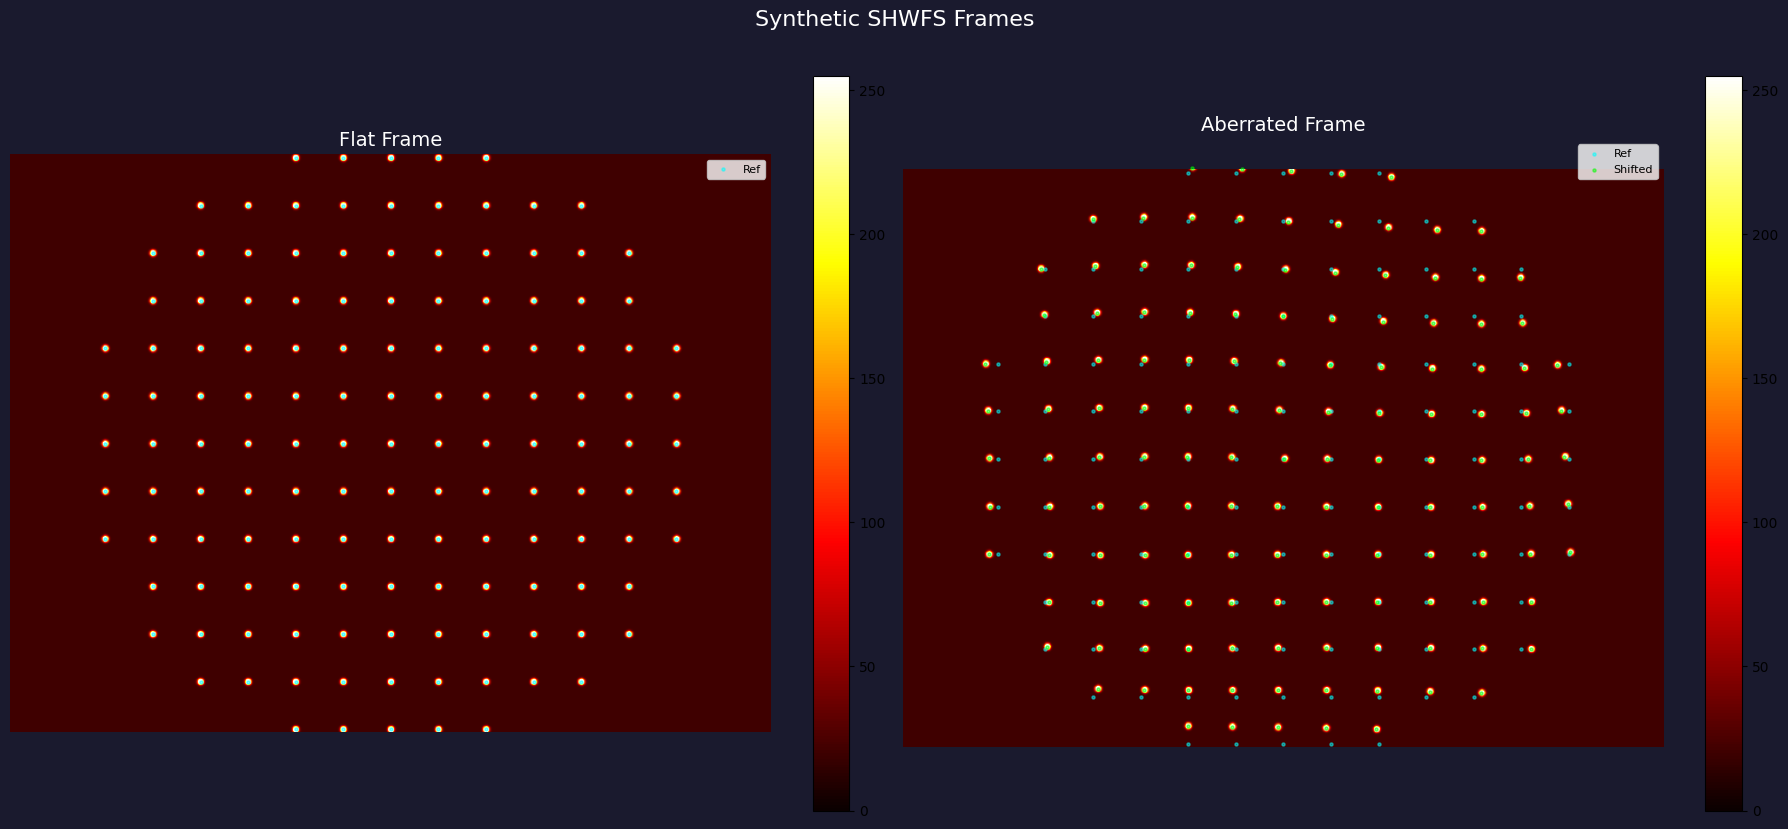

Saved: shwfs_frames.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, frame, title in zip(axes, [flat, img], ['Flat Frame', 'Aberrated Frame']):
    vmin, vmax = 0, min(flat.max(), 255)
    im = ax.imshow(frame, cmap='hot', vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=14, color='white')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)
    # Overlay lenslet positions
    ax.scatter(positions[:, 0], positions[:, 1], c='cyan', s=5, alpha=0.5, label='Ref')
    if title == 'Aberrated Frame':
        ax.scatter(shifted[:, 0], shifted[:, 1], c='lime', s=5, alpha=0.5, label='Shifted')
    ax.legend(fontsize=8)

fig.patch.set_facecolor('#1a1a2e')
fig.suptitle('Synthetic SHWFS Frames', fontsize=16, color='white', y=1.02)
plt.tight_layout()
plt.savefig('shwfs_frames.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved: shwfs_frames.png")



## 8.1 Advanced Wavefront Analysis & Telemetry Diagrams

We generate several telemetry plots to analyze the wavefront aberrations and spot displacements in detail:
1. **Spot Displacement Vector Field (Quiver Plot):** Shows the local gradient $\nabla W$ of the wavefront at each lenslet.
2. **Reconstructed 2D Phase Screen:** A color map of the wavefront phase $W(x, y)$ inside the circular pupil.
3. **3D Wavefront Surface Map:** An elevation plot showing the peak-to-valley shape of the distorted phase screen.
4. **Zernike Mode Contributions:** A bar chart of the input Zernike modal coefficients.



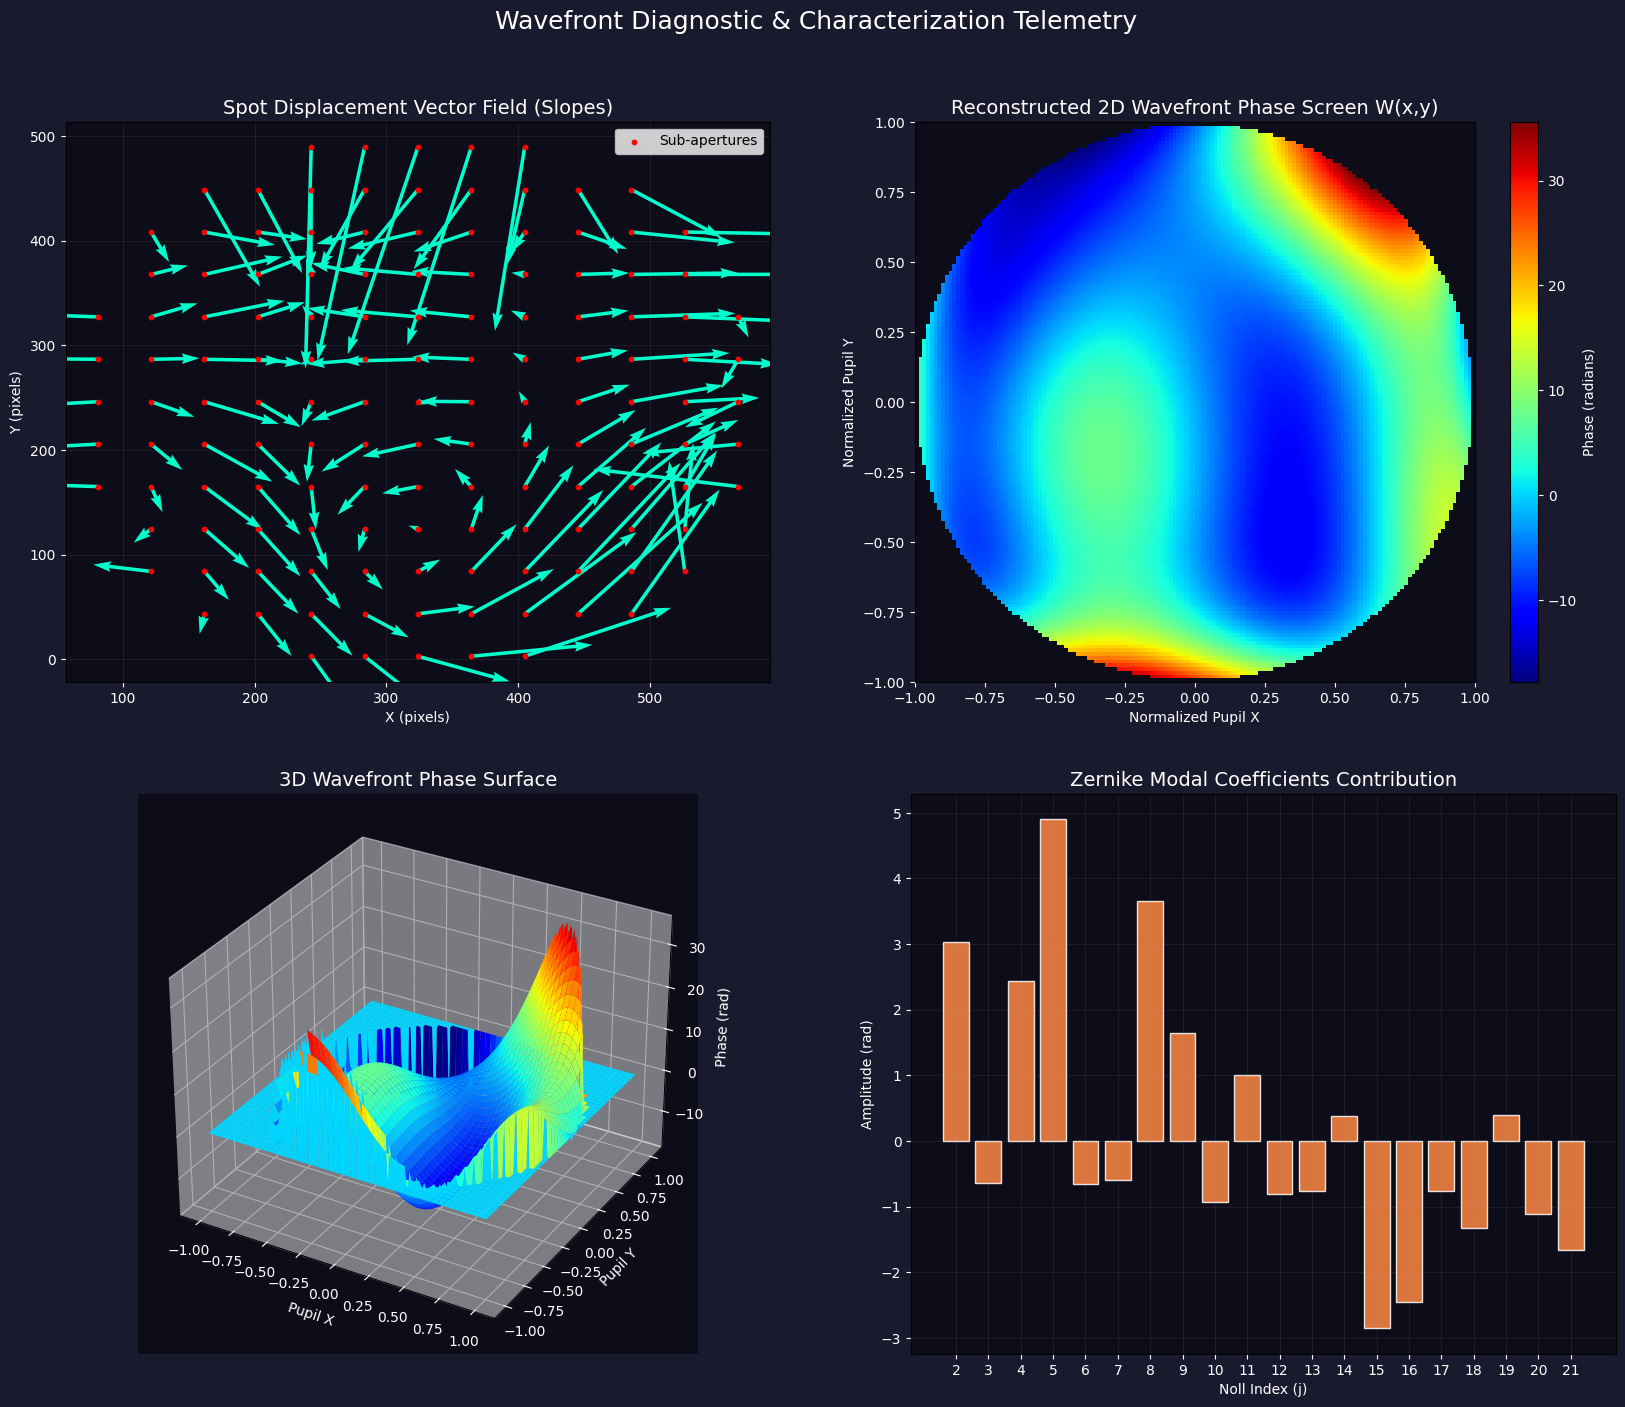

Saved: visualizations/wavefront_telemetry.png


In [9]:
def zernike_eval_grid(n, m, xx, yy):
    rho = np.hypot(xx, yy)
    theta = np.arctan2(yy, xx)
    abs_m = abs(m)
    R = np.zeros_like(xx)
    for s in range((n - abs_m)//2 + 1):
        c = zernike_coeff(n, m, s)
        p = n - 2*s
        R += c * (rho ** p) if p > 0 else c
    norm = math.sqrt(n + 1) if m == 0 else math.sqrt(2 * (n + 1))
    R *= norm
    if m >= 0:
        return R * np.cos(abs_m * theta)
    else:
        return R * np.sin(abs_m * theta)

def compute_wavefront_phase(coeffs, grid_size=150):
    x = np.linspace(-1, 1, grid_size)
    y = np.linspace(-1, 1, grid_size)
    xx, yy = np.meshgrid(x, y)
    rho = np.hypot(xx, yy)
    mask = rho <= 1.0
    phase = np.zeros_like(xx)
    for j in range(len(coeffs)):
        n, m = noll_to_nm(j + 2)
        phase += coeffs[j] * zernike_eval_grid(n, m, xx, yy)
    phase[~mask] = np.nan
    return xx, yy, phase

xx, yy, phase_screen = compute_wavefront_phase(coeffs_truth)

fig = plt.figure(figsize=(20, 16))
fig.patch.set_facecolor('#1a1a2e')

# 1. Quiver Plot of Spot Shifts
ax1 = fig.add_subplot(2, 2, 1)
ax1.set_facecolor('#0d0d1a')
ax1.quiver(positions[:, 0], positions[:, 1], dx, dy, color='#00ffcc', scale=50, width=0.005)
ax1.scatter(positions[:, 0], positions[:, 1], color='red', s=10, label='Sub-apertures')
ax1.set_title("Spot Displacement Vector Field (Slopes)", color='white', fontsize=14)
ax1.set_xlabel("X (pixels)", color='white')
ax1.set_ylabel("Y (pixels)", color='white')
ax1.tick_params(colors='white')
ax1.legend()
ax1.grid(True, alpha=0.1)

# 2. 2D Wavefront Phase Map
ax2 = fig.add_subplot(2, 2, 2)
ax2.set_facecolor('#0d0d1a')
im2 = ax2.imshow(phase_screen, extent=[-1, 1, -1, 1], cmap='jet', origin='lower')
ax2.set_title("Reconstructed 2D Wavefront Phase Screen W(x,y)", color='white', fontsize=14)
ax2.set_xlabel("Normalized Pupil X", color='white')
ax2.set_ylabel("Normalized Pupil Y", color='white')
ax2.tick_params(colors='white')
cbar2 = plt.colorbar(im2, ax=ax2)
cbar2.set_label('Phase (radians)', color='white')
cbar2.ax.tick_params(colors='white')

# 3. 3D Wavefront Surface Plot
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
ax3.set_facecolor('#0d0d1a')
xx_m, yy_m = xx.copy(), yy.copy()
phase_m = np.nan_to_num(phase_screen, nan=0.0)
rho = np.hypot(xx_m, yy_m)
phase_m[rho > 1.0] = 0.0

surf = ax3.plot_surface(xx_m, yy_m, phase_m, facecolors=plt.cm.jet((phase_m - np.nanmin(phase_screen)) / (np.nanmax(phase_screen) - np.nanmin(phase_screen))), shade=False, linewidth=0, antialiased=True)
ax3.set_title("3D Wavefront Phase Surface", color='white', fontsize=14)
ax3.set_xlabel("Pupil X", color='white')
ax3.set_ylabel("Pupil Y", color='white')
ax3.set_zlabel("Phase (rad)", color='white')
ax3.tick_params(colors='white')
ax3.xaxis.label.set_color('white')
ax3.yaxis.label.set_color('white')
ax3.zaxis.label.set_color('white')

# 4. Zernike Coefficients Contribution
ax4 = fig.add_subplot(2, 2, 4)
ax4.set_facecolor('#0d0d1a')
modes_idx = np.arange(2, NMODES + 2)
ax4.bar(modes_idx, coeffs_truth, color='#ff8844', alpha=0.85, edgecolor='white')
ax4.set_title("Zernike Modal Coefficients Contribution", color='white', fontsize=14)
ax4.set_xlabel("Noll Index (j)", color='white')
ax4.set_ylabel("Amplitude (rad)", color='white')
ax4.set_xticks(modes_idx)
ax4.tick_params(colors='white')
ax4.grid(True, alpha=0.1)

plt.suptitle("Wavefront Diagnostic & Characterization Telemetry", color='white', fontsize=18, y=0.95)
plt.savefig('visualizations/wavefront_telemetry.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved: visualizations/wavefront_telemetry.png")



## 8.2 Educational Gallery: Reference Zernike Mode Shapes

To understand the optical aberrations represented by the Noll coefficients, we display a grid of the first 6 active Zernike modes:

* **j = 2 (Tip / X-Tilt):** Linear tilt along the X axis.
* **j = 3 (Tilt / Y-Tilt):** Linear tilt along the Y axis.
* **j = 4 (Defocus):** Quadratic radial curvature.
* **j = 5 (Oblique Astigmatism):** Saddle-like distortion rotated 45 degrees.
* **j = 6 (Vertical Astigmatism):** Saddle-like distortion along the axes.
* **j = 7 (Vertical Coma):** Flare-like coma aberration along the Y axis.



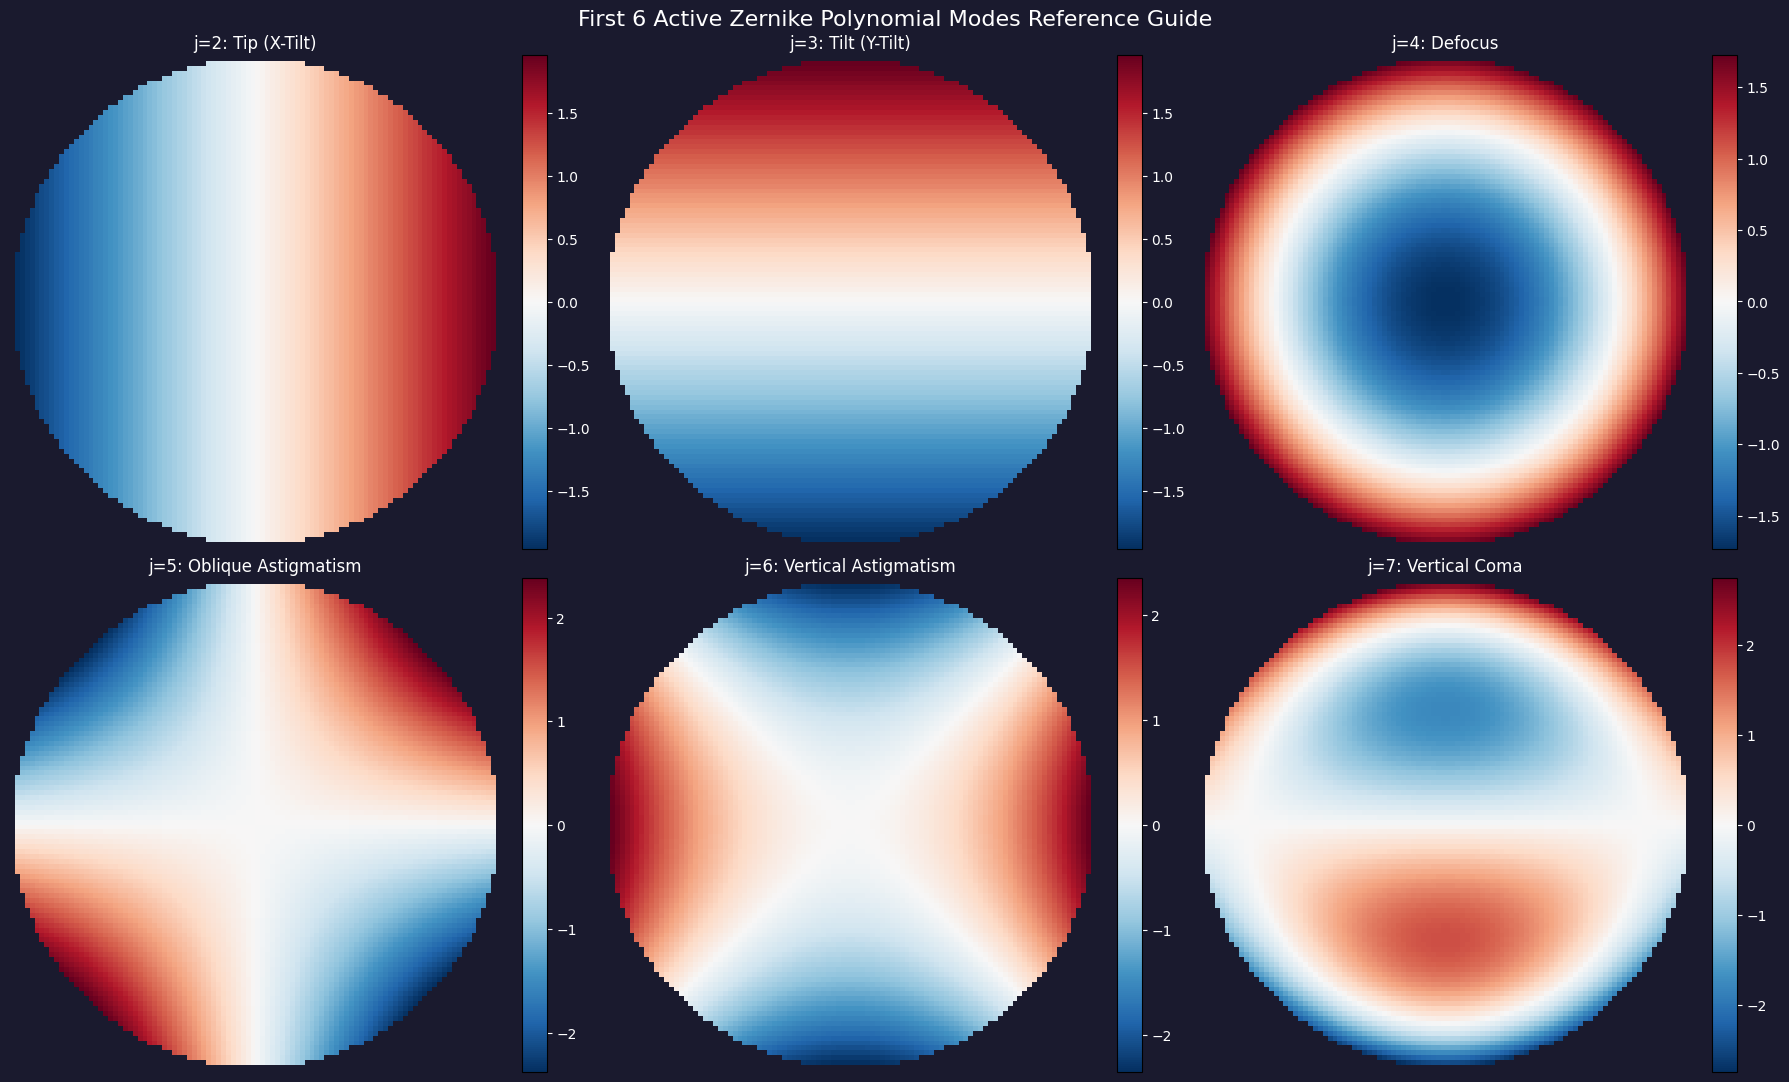

Saved: visualizations/zernike_modes_reference.png


In [10]:
zernike_names = {
    2: "j=2: Tip (X-Tilt)",
    3: "j=3: Tilt (Y-Tilt)",
    4: "j=4: Defocus",
    5: "j=5: Oblique Astigmatism",
    6: "j=6: Vertical Astigmatism",
    7: "j=7: Vertical Coma"
}

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.patch.set_facecolor('#1a1a2e')

x_z = np.linspace(-1, 1, 100)
y_z = np.linspace(-1, 1, 100)
xx_z, yy_z = np.meshgrid(x_z, y_z)
rho_z = np.hypot(xx_z, yy_z)
mask_z = rho_z <= 1.0

for idx, j_mode in enumerate(range(2, 8)):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    ax.set_facecolor('#0d0d1a')
    
    n_z, m_z = noll_to_nm(j_mode)
    z_grid = zernike_eval_grid(n_z, m_z, xx_z, yy_z)
    z_grid[~mask_z] = np.nan
    
    im_z = ax.imshow(z_grid, extent=[-1, 1, -1, 1], cmap='RdBu_r', origin='lower')
    ax.set_title(zernike_names[j_mode], color='white', fontsize=12)
    ax.axis('off')
    cbar_z = plt.colorbar(im_z, ax=ax, fraction=0.046, pad=0.04)
    cbar_z.ax.tick_params(colors='white')

plt.suptitle("First 6 Active Zernike Polynomial Modes Reference Guide", color='white', fontsize=16, y=0.98)
plt.tight_layout()
plt.savefig('visualizations/zernike_modes_reference.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved: visualizations/zernike_modes_reference.png")



## 8.3 Turbulence Statistical Validation

According to atmospheric turbulence theory, the focal spot displacements $(\Delta x, \Delta y)$ should follow a normal distribution centered at 0. We verify this by plotting a histogram of the shifts in X and Y, fitting a Gaussian profile to show the physical correctness of our synthetic generator.



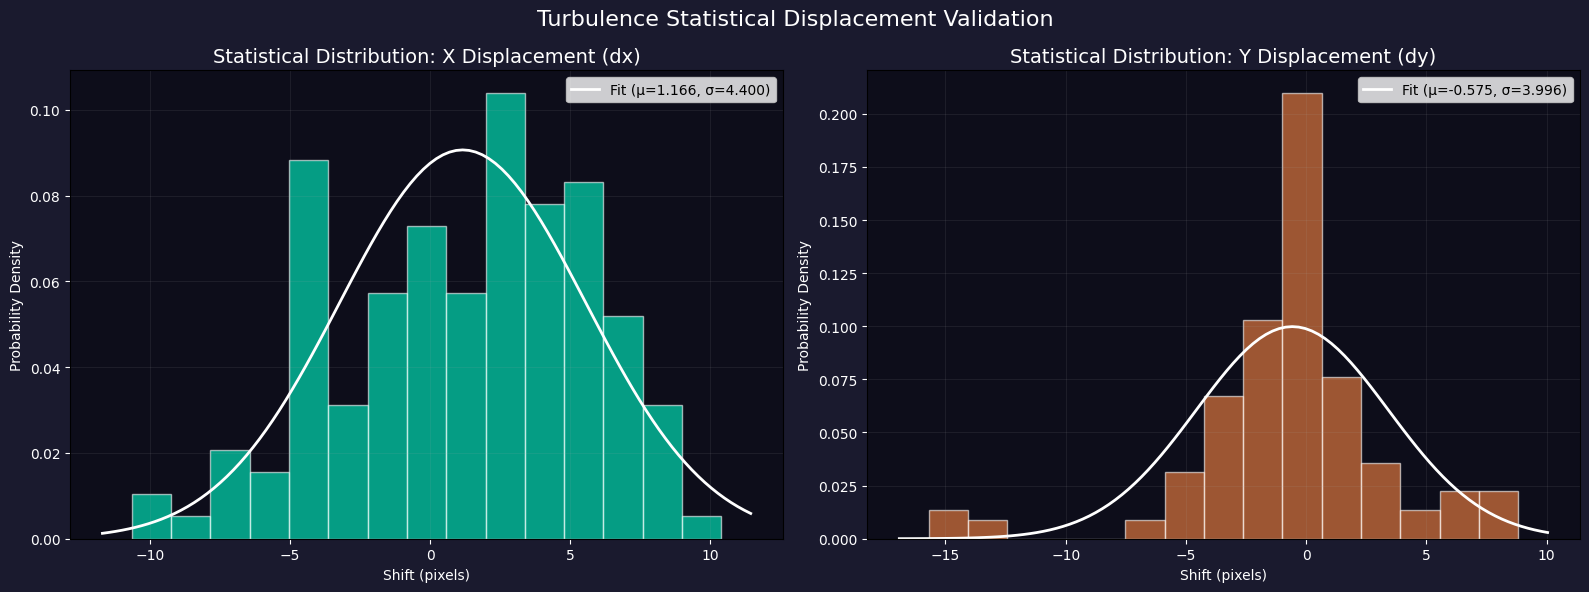

Saved: visualizations/turbulence_statistics.png


In [11]:
from scipy.stats import norm

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#1a1a2e')

for ax, shift_data, label, color in zip(axes, [dx, dy], ['X Displacement (dx)', 'Y Displacement (dy)'], ['#00ffcc', '#ff8844']):
    ax.set_facecolor('#0d0d1a')
    # Plot histogram
    n_bins, bins, patches = ax.hist(shift_data, bins=15, density=True, alpha=0.6, color=color, edgecolor='white')
    
    # Fit normal distribution
    mu, std = norm.fit(shift_data)
    xmin, xmax = ax.get_xlim()
    x_fit = np.linspace(xmin, xmax, 100)
    y_fit = norm.pdf(x_fit, mu, std)
    
    ax.plot(x_fit, y_fit, 'w-', lw=2, label=f'Fit (μ={mu:.3f}, σ={std:.3f})')
    ax.set_title(f'Statistical Distribution: {label}', color='white', fontsize=14)
    ax.set_xlabel('Shift (pixels)', color='white')
    ax.set_ylabel('Probability Density', color='white')
    ax.tick_params(colors='white')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.1)

plt.suptitle("Turbulence Statistical Displacement Validation", color='white', fontsize=16, y=0.98)
plt.tight_layout()
plt.savefig('visualizations/turbulence_statistics.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved: visualizations/turbulence_statistics.png")



## 8.4 Wave Optics & Focal Plane Diagnostics

In this section, we analyze the wavefront using wave optics principles:
1. **Simulated Optical Interferogram:** Mimics a physical interferometer by interfering the aberrated wavefront with a tilted flat reference beam. Curved fringes highlight the phase aberrations.
2. **Diffraction-Limited vs. Aberrated Focal Plane PSF:** Computes the 2D Fast Fourier Transform (FFT) of the complex pupil function $A(x,y)e^{iW(x,y)}$ to see how the image of a point source degrades compared to a perfect Airy Disk.
3. **1D Wavefront Cuts:** Slices the phase screen vertically and horizontally to show the exact micron-level physical shape profile.



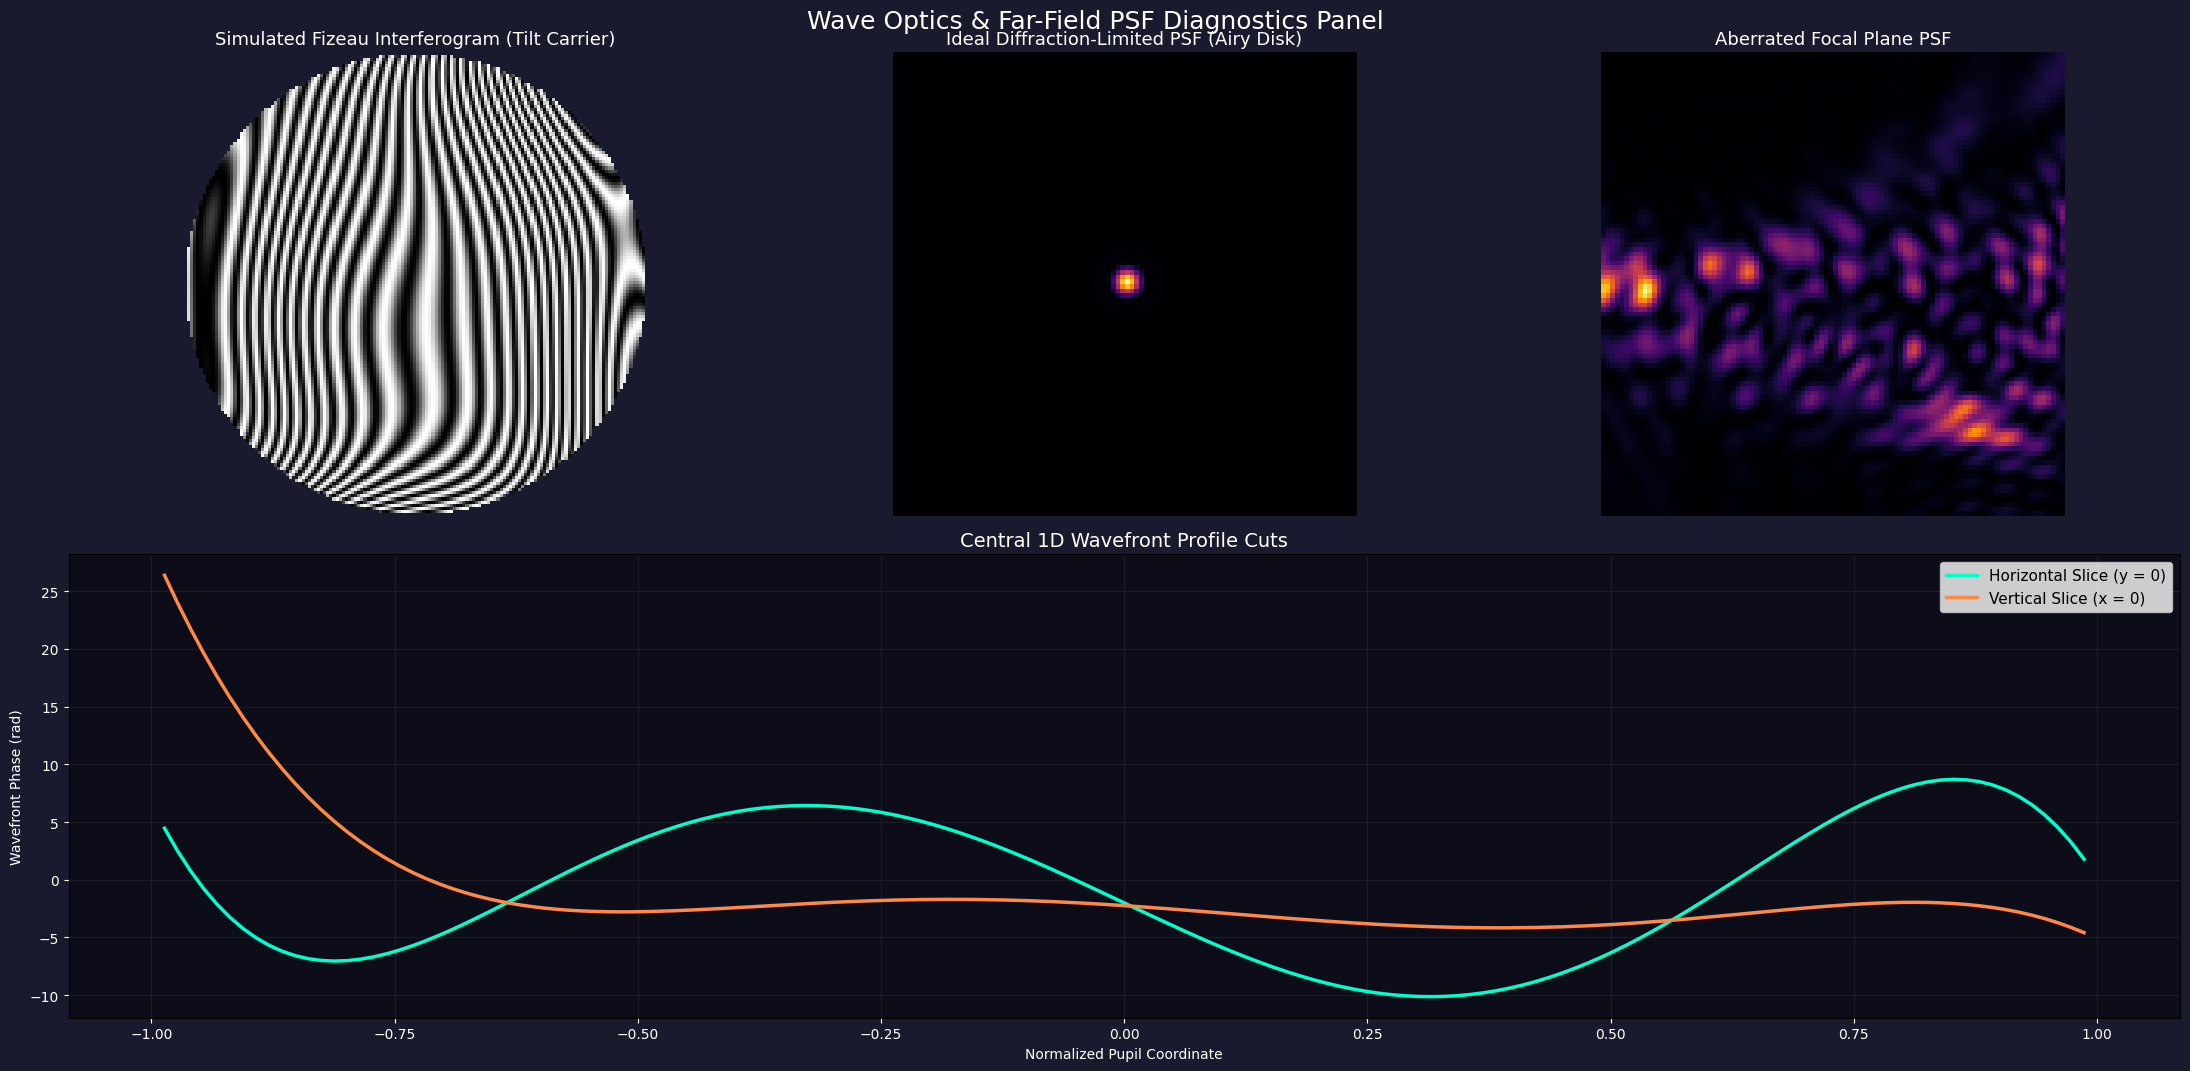

Saved: visualizations/wave_optics_diagnostics.png


In [12]:
def compute_far_field_psf(phase, grid_size=150, pad_factor=4):
    x = np.linspace(-1, 1, grid_size)
    y = np.linspace(-1, 1, grid_size)
    xx, yy = np.meshgrid(x, y)
    rho = np.hypot(xx, yy)
    pupil = (rho <= 1.0).astype(complex)
    
    phase_clean = np.nan_to_num(phase, nan=0.0)
    pupil_function = pupil * np.exp(1j * phase_clean)
    
    # Pad array for high-resolution FFT (Airy disk details)
    pad_size = grid_size * pad_factor
    padded_pupil = np.zeros((pad_size, pad_size), dtype=complex)
    start = (pad_size - grid_size) // 2
    padded_pupil[start:start+grid_size, start:start+grid_size] = pupil_function
    
    # Compute FFT
    fft_field = np.fft.fftshift(np.fft.fft2(padded_pupil))
    psf = np.abs(fft_field) ** 2
    
    # Normalize PSF
    psf /= psf.max()
    
    # Zoom in on central core
    zoom = grid_size // 3
    center = pad_size // 2
    psf_zoom = psf[center-zoom:center+zoom, center-zoom:center+zoom]
    return psf_zoom

# 1. Interferogram calculation (with 12 vertical carrier fringes)
intensity = 1.0 + np.cos(2 * np.pi * 12 * xx + np.nan_to_num(phase_screen, nan=0.0))
# Mask outside pupil
rho_grid = np.hypot(xx, yy)
intensity[rho_grid > 1.0] = np.nan

# 2. PSF calculations
psf_airy = compute_far_field_psf(np.zeros_like(phase_screen))
psf_aberrated = compute_far_field_psf(phase_screen)

# 3. 1D slices
mid_idx = phase_screen.shape[0] // 2
x_coords = np.linspace(-1, 1, phase_screen.shape[1])
h_slice = phase_screen[mid_idx, :]  # Horizontal slice (y=0)
v_slice = phase_screen[:, mid_idx]  # Vertical slice (x=0)

fig = plt.figure(figsize=(22, 11))
fig.patch.set_facecolor('#1a1a2e')

# Panel 1: Interferogram
ax_int = fig.add_subplot(2, 3, 1)
ax_int.set_facecolor('#0d0d1a')
im_int = ax_int.imshow(intensity, extent=[-1, 1, -1, 1], cmap='gray', origin='lower')
ax_int.set_title("Simulated Fizeau Interferogram (Tilt Carrier)", color='white', fontsize=13)
ax_int.axis('off')

# Panel 2: Airy Disk (Ideal PSF)
ax_airy = fig.add_subplot(2, 3, 2)
ax_airy.set_facecolor('#0d0d1a')
im_airy = ax_airy.imshow(psf_airy, cmap='inferno', origin='lower')
ax_airy.set_title("Ideal Diffraction-Limited PSF (Airy Disk)", color='white', fontsize=13)
ax_airy.axis('off')

# Panel 3: Aberrated PSF
ax_ab = fig.add_subplot(2, 3, 3)
ax_ab.set_facecolor('#0d0d1a')
im_ab = ax_ab.imshow(psf_aberrated, cmap='inferno', origin='lower')
ax_ab.set_title("Aberrated Focal Plane PSF", color='white', fontsize=13)
ax_ab.axis('off')

# Panel 4 & 5 combined (spanning columns 4 and 5 on row 2) for 1D slices
ax_slice = fig.add_subplot(2, 1, 2)
ax_slice.set_facecolor('#0d0d1a')
ax_slice.plot(x_coords, h_slice, color='#00ffcc', lw=2.5, label='Horizontal Slice (y = 0)')
ax_slice.plot(x_coords, v_slice, color='#ff8844', lw=2.5, label='Vertical Slice (x = 0)')
ax_slice.set_title("Central 1D Wavefront Profile Cuts", color='white', fontsize=14)
ax_slice.set_xlabel("Normalized Pupil Coordinate", color='white')
ax_slice.set_ylabel("Wavefront Phase (rad)", color='white')
ax_slice.tick_params(colors='white')
ax_slice.legend(fontsize=11)
ax_slice.grid(True, alpha=0.1)

plt.suptitle("Wave Optics & Far-Field PSF Diagnostics Panel", color='white', fontsize=18, y=0.97)
plt.tight_layout()
plt.savefig('visualizations/wave_optics_diagnostics.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved: visualizations/wave_optics_diagnostics.png")



## 9. Generate ML Training Dataset



In [13]:
def noll_variance(j, D_r0=8.0):
    if j <= 3: return 0.4874 * (D_r0 ** (5/3)) * 0.582
    return 0.4874 * (D_r0 ** (5/3)) * 0.294 * (j - 1) ** (-math.sqrt(3)/2)

def generate_dataset(n_samples, seed=123):
    """Generate (displacements, coefficients) pairs."""
    rng = np.random.RandomState(seed)
    disp = np.zeros((n_samples, NSPOTS * 2), dtype=np.float32)
    coef = np.zeros((n_samples, NMODES), dtype=np.float32)
    for i in range(n_samples):
        c = np.array([rng.randn() * math.sqrt(noll_variance(j + 2)) for j in range(NMODES)])
        dx_i, dy_i = shifts_from_wavefront(c)
        disp[i] = np.concatenate([dx_i, dy_i])
        coef[i] = c
    return disp, coef

print("Generating ML training dataset...")
N_TRAIN = 50000
N_VAL = 10000
N_TEST = 5000

X_train, Y_train = generate_dataset(N_TRAIN, seed=42)
X_val, Y_val = generate_dataset(N_VAL, seed=99)
X_test, Y_test = generate_dataset(N_TEST, seed=123)

np.savez('data_ai/dataset.npz',
         displacements=np.concatenate([X_train, X_val, X_test]),
         coefficients=np.concatenate([Y_train, Y_val, Y_test]))

print(f"  Train: {X_train.shape}")
print(f"  Val:   {X_val.shape}")
print(f"  Test:  {X_test.shape}")
print(f"  Total: {os.path.getsize('data_ai/dataset.npz')//1024**2:.1f} MB")



Generating ML training dataset...
  Train: (50000, 274)
  Val:   (10000, 274)
  Test:  (5000, 274)
  Total: 72.0 MB


## 10. Define & Train ML Models (MLP + CNN)



In [14]:
class WavefrontMLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512), nn.LayerNorm(512), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(512, 256), nn.LayerNorm(256), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(256, 128), nn.LayerNorm(128), nn.ReLU(),
            nn.Linear(128, output_dim),
        )
    def forward(self, x):
        return self.net(x)

class WavefrontCNN(nn.Module):
    def __init__(self, output_dim, grid_h=13, grid_w=17):
        super().__init__()
        self.grid_h, self.grid_w = grid_h, grid_w
        self.cnn = nn.Sequential(
            nn.Conv2d(2, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 128), nn.ReLU(),
            nn.Linear(128, output_dim),
        )
    def forward(self, x):
        return self.cnn(x)

# Build spatial grid for CNN
def build_spatial_grid(disp_batch):
    B = disp_batch.shape[0]
    xn_vals = (positions[:, 0] - W/2) / PITCH_PX
    yn_vals = (positions[:, 1] - H/2) / PITCH_PX
    u = np.round(xn_vals).astype(int)
    v = np.round(yn_vals).astype(int)
    u_min, u_max = u.min(), u.max()
    v_min, v_max = v.min(), v.max()
    grid_w_cnn = int(u_max - u_min + 1)
    grid_h_cnn = int(v_max - v_min + 1)
    grid = np.zeros((B, 2, grid_h_cnn, grid_w_cnn), dtype=np.float32)
    for k in range(NSPOTS):
        row = int(v[k] - v_min)
        col = int(u[k] - u_min)
        grid[:, 0, row, col] = disp_batch[:, k]
        grid[:, 1, row, col] = disp_batch[:, NSPOTS + k]
    return torch.from_numpy(grid), grid_h_cnn, grid_w_cnn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

# MLP
print("\n--- Training MLP ---")
mlp = WavefrontMLP(input_dim=NSPOTS*2, output_dim=NMODES).to(device)
opt_mlp = torch.optim.AdamW(mlp.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.MSELoss()

train_loader = DataLoader(TensorDataset(torch.from_numpy(X_train), torch.from_numpy(Y_train)), batch_size=128, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.from_numpy(X_val), torch.from_numpy(Y_val)), batch_size=128)

mlp_train_losses = []
mlp_val_losses = []

best_val = float('inf')
for epoch in range(15):
    mlp.train()
    tl = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt_mlp.zero_grad()
        loss = loss_fn(mlp(xb), yb)
        loss.backward()
        opt_mlp.step()
        tl += loss.item() * len(xb)
    tl /= len(train_loader.dataset)
    
    mlp.eval()
    vl = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            vl += loss_fn(mlp(xb.to(device)), yb.to(device)).item() * len(xb)
    vl /= len(val_loader.dataset)
    
    mlp_train_losses.append(tl)
    mlp_val_losses.append(vl)
    
    print(f"  Epoch {epoch+1:2d}: train_loss = {tl:.6f}, val_loss = {vl:.6f}")
    if vl < best_val:
        best_val = vl
        torch.save({'model_state_dict': mlp.state_dict()}, 'ml_checkpoints/local/best_mlp.pt')
        print(f"    -> saved (best)")

# CNN
print("\n--- Training CNN ---")
grid, gh, gw = build_spatial_grid(X_train)
grid_val, _, _ = build_spatial_grid(X_val)
cnn = WavefrontCNN(output_dim=NMODES, grid_h=gh, grid_w=gw).to(device)
opt_cnn = torch.optim.AdamW(cnn.parameters(), lr=1e-3, weight_decay=1e-4)

cnn_train = TensorDataset(grid, torch.from_numpy(Y_train))
cnn_val = TensorDataset(grid_val, torch.from_numpy(Y_val))
cnn_loader = DataLoader(cnn_train, batch_size=64, shuffle=True)
cnn_val_loader = DataLoader(cnn_val, batch_size=64)

cnn_train_losses = []
cnn_val_losses = []

best_val = float('inf')
for epoch in range(15):
    cnn.train()
    tl = 0.0
    for xb, yb in cnn_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt_cnn.zero_grad()
        loss = loss_fn(cnn(xb), yb)
        loss.backward()
        opt_cnn.step()
        tl += loss.item() * len(xb)
    tl /= len(cnn_loader.dataset)
    
    cnn.eval()
    vl = 0.0
    with torch.no_grad():
        for xb, yb in cnn_val_loader:
            vl += loss_fn(cnn(xb.to(device)), yb.to(device)).item() * len(xb)
    vl /= len(cnn_val_loader.dataset)
    
    cnn_train_losses.append(tl)
    cnn_val_losses.append(vl)
    
    print(f"  Epoch {epoch+1:2d}: train_loss = {tl:.6f}, val_loss = {vl:.6f}")
    if vl < best_val:
        best_val = vl
        torch.save({'model_state_dict': cnn.state_dict()}, 'ml_checkpoints/local/best_cnn.pt')
        print(f"    -> saved (best)")



Training on: cuda

--- Training MLP ---
  Epoch  1: train_loss = 0.153015, val_loss = 0.055402
    -> saved (best)
  Epoch  2: train_loss = 0.079560, val_loss = 0.047389
    -> saved (best)
  Epoch  3: train_loss = 0.071056, val_loss = 0.038313
    -> saved (best)
  Epoch  4: train_loss = 0.059803, val_loss = 0.024353
    -> saved (best)
  Epoch  5: train_loss = 0.049263, val_loss = 0.018706
    -> saved (best)
  Epoch  6: train_loss = 0.044970, val_loss = 0.013936
    -> saved (best)
  Epoch  7: train_loss = 0.042495, val_loss = 0.012580
    -> saved (best)
  Epoch  8: train_loss = 0.040179, val_loss = 0.010832
    -> saved (best)
  Epoch  9: train_loss = 0.038697, val_loss = 0.011583
  Epoch 10: train_loss = 0.037326, val_loss = 0.009695
    -> saved (best)
  Epoch 11: train_loss = 0.036340, val_loss = 0.010703
  Epoch 12: train_loss = 0.035766, val_loss = 0.010188
  Epoch 13: train_loss = 0.034945, val_loss = 0.008283
    -> saved (best)
  Epoch 14: train_loss = 0.034551, val_loss =

## 11. Test Set Evaluation



In [15]:
print("=== Test Set Evaluation ===")
mlp.eval(); cnn.eval()
X_test_t = torch.from_numpy(X_test).to(device)
Y_test_t = torch.from_numpy(Y_test).to(device)

with torch.no_grad():
    pred_mlp = mlp(X_test_t)
    mlp_mse = loss_fn(pred_mlp, Y_test_t).item()
    pred_cnn = cnn(build_spatial_grid(X_test)[0].to(device))
    cnn_mse = loss_fn(pred_cnn, Y_test_t).item()

print(f"  MLP Test MSE: {mlp_mse:.6f}")
print(f"  CNN Test MSE: {cnn_mse:.6f}")
# Per-mode correlation
mlp_preds_np = pred_mlp.cpu().numpy()
cnn_preds_np = pred_cnn.cpu().numpy()

mlp_corrs = []
cnn_corrs = []
for j in range(NMODES):
    c_mlp = np.corrcoef(Y_test[:, j], mlp_preds_np[:, j])[0, 1]
    c_cnn = np.corrcoef(Y_test[:, j], cnn_preds_np[:, j])[0, 1]
    mlp_corrs.append(c_mlp)
    cnn_corrs.append(c_cnn)
    
print(f"  MLP mean correlation: {np.mean(mlp_corrs):.4f}")
print(f"  CNN mean correlation: {np.mean(cnn_corrs):.4f}")



=== Test Set Evaluation ===
  MLP Test MSE: 0.008965
  CNN Test MSE: 0.001957
  MLP mean correlation: 0.9962
  CNN mean correlation: 0.9997


## 11.1 Model Performance Diagnostics Dashboard

We visualize the training loss history, individual regression predictions, and comparison metrics across all modes.



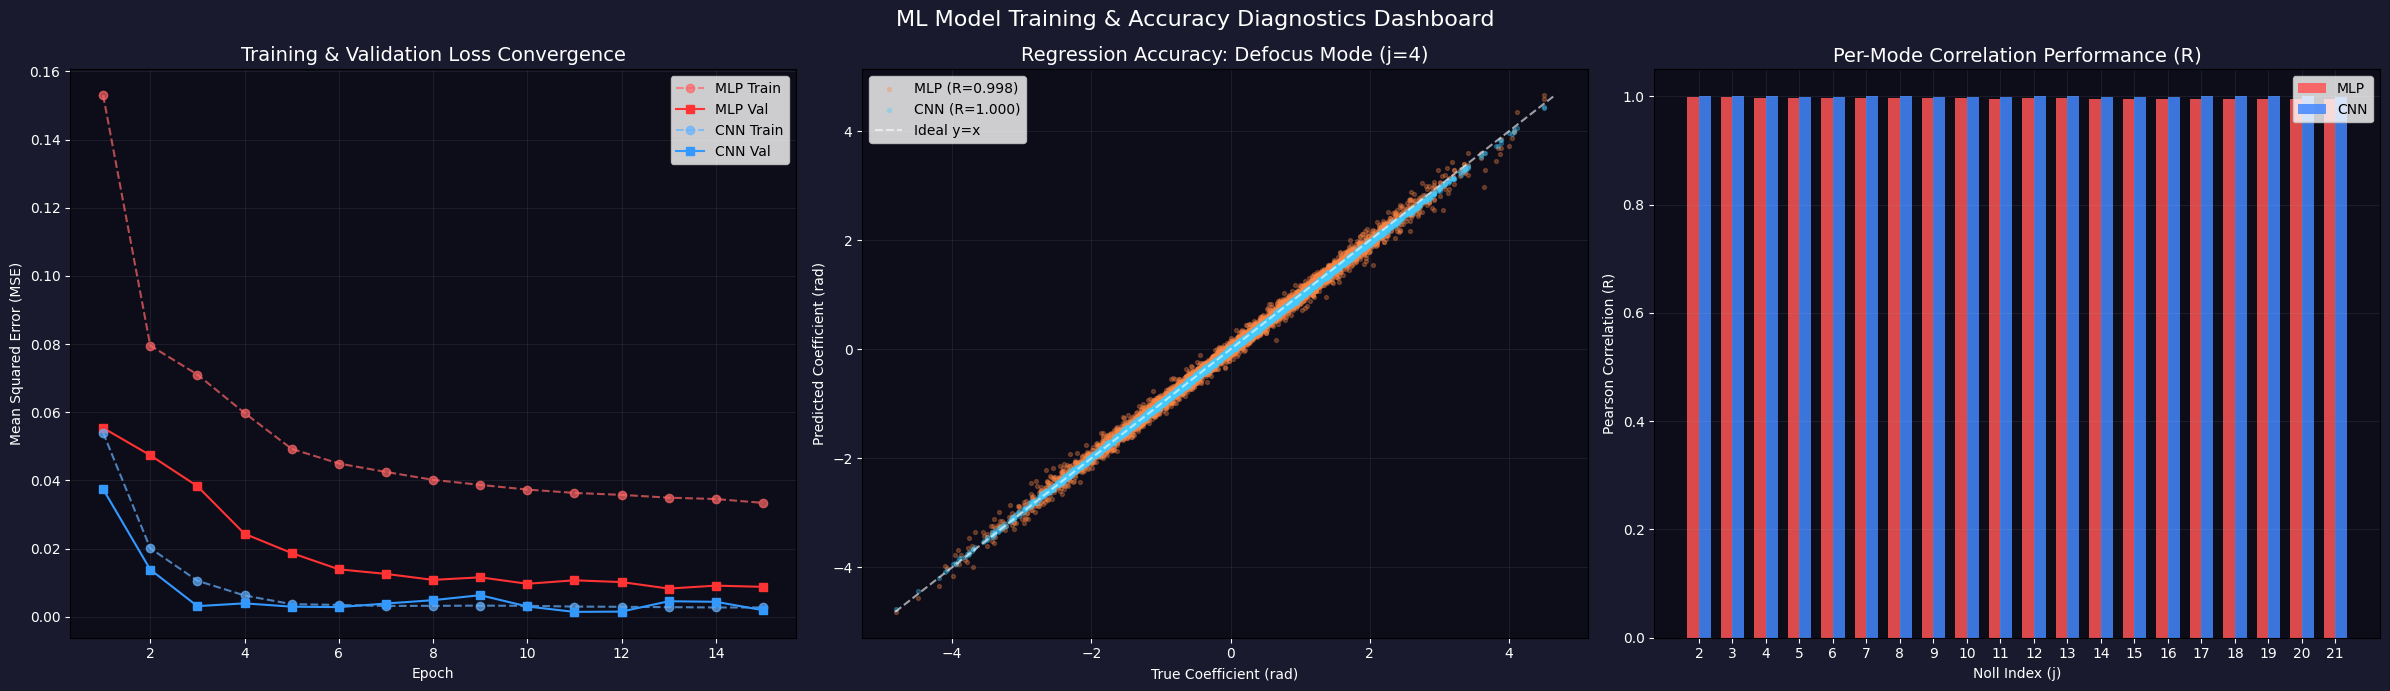

Saved: visualizations/ml_diagnostics.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
fig.patch.set_facecolor('#1a1a2e')

# 1. Loss Curves
ax_loss = axes[0]
ax_loss.set_facecolor('#0d0d1a')
epochs = np.arange(1, 16)
ax_loss.plot(epochs, mlp_train_losses, 'o--', color='#ff6666', alpha=0.7, label='MLP Train')
ax_loss.plot(epochs, mlp_val_losses, 's-', color='#ff3333', label='MLP Val')
ax_loss.plot(epochs, cnn_train_losses, 'o--', color='#66b2ff', alpha=0.7, label='CNN Train')
ax_loss.plot(epochs, cnn_val_losses, 's-', color='#3399ff', label='CNN Val')
ax_loss.set_title("Training & Validation Loss Convergence", color='white', fontsize=14)
ax_loss.set_xlabel("Epoch", color='white')
ax_loss.set_ylabel("Mean Squared Error (MSE)", color='white')
ax_loss.tick_params(colors='white')
ax_loss.grid(True, alpha=0.1)
ax_loss.legend()

# 2. Scatter Plot: True vs Predicted (Defocus mode, j=4, which is index 2)
ax_scat = axes[1]
ax_scat.set_facecolor('#0d0d1a')
true_defocus = Y_test[:, 2]
pred_defocus_mlp = mlp_preds_np[:, 2]
pred_defocus_cnn = cnn_preds_np[:, 2]

ax_scat.scatter(true_defocus, pred_defocus_mlp, color='#ff8844', alpha=0.3, s=8, label=f'MLP (R={mlp_corrs[2]:.3f})')
ax_scat.scatter(true_defocus, pred_defocus_cnn, color='#44ccff', alpha=0.3, s=8, label=f'CNN (R={cnn_corrs[2]:.3f})')

# Diagonal line representing perfect prediction
min_val = min(true_defocus.min(), pred_defocus_mlp.min(), pred_defocus_cnn.min())
max_val = max(true_defocus.max(), pred_defocus_mlp.max(), pred_defocus_cnn.max())
ax_scat.plot([min_val, max_val], [min_val, max_val], 'w--', alpha=0.6, label='Ideal y=x')

ax_scat.set_title("Regression Accuracy: Defocus Mode (j=4)", color='white', fontsize=14)
ax_scat.set_xlabel("True Coefficient (rad)", color='white')
ax_scat.set_ylabel("Predicted Coefficient (rad)", color='white')
ax_scat.tick_params(colors='white')
ax_scat.grid(True, alpha=0.1)
ax_scat.legend()

# 3. Per-Mode Correlation Comparison
ax_corr = axes[2]
ax_corr.set_facecolor('#0d0d1a')
modes_idx = np.arange(2, NMODES + 2)
width = 0.35
ax_corr.bar(modes_idx - width/2, mlp_corrs, width, color='#ff5555', alpha=0.85, label='MLP')
ax_corr.bar(modes_idx + width/2, cnn_corrs, width, color='#4488ff', alpha=0.85, label='CNN')
ax_corr.set_title("Per-Mode Correlation Performance (R)", color='white', fontsize=14)
ax_corr.set_xlabel("Noll Index (j)", color='white')
ax_corr.set_ylabel("Pearson Correlation (R)", color='white')
ax_corr.set_xticks(modes_idx)
ax_corr.tick_params(colors='white')
ax_corr.grid(True, alpha=0.1)
ax_corr.legend()

plt.suptitle("ML Model Training & Accuracy Diagnostics Dashboard", color='white', fontsize=16, y=0.98)
plt.tight_layout()
plt.savefig('visualizations/ml_diagnostics.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved: visualizations/ml_diagnostics.png")



## 12. Export Config for C Pipeline



In [18]:
# Write an updated config with totlenses matching our lenslet count
os.makedirs('rippra/config', exist_ok=True)
with open('rippra/config/system.conf', 'w') as f:
    f.write(f"""# RIPPA system configuration (auto-generated for synthetic data)
camera_pixsize = {CFG['camera_pixsize']}
frame_width    = {CFG['frame_width']}
frame_height   = {CFG['frame_height']}
totlenses      = {NSPOTS + 5}
flength        = {CFG['flength']}
pitch          = {CFG['pitch']}
sa_radius      = {CFG['sa_radius']}
pupil_radius   = {CFG['pupil_radius']}
wavelength     = {CFG['wavelength']}
thresh_binary  = {CFG['thresh_binary']}
centroid_percent = {CFG['centroid_percent']}
coarse_grid_radius = {CFG['coarse_grid_radius']}
zernike_nmax   = {CFG['zernike_nmax']}
dm_nact_x      = {CFG['dm_nact_x']}
dm_nact_y      = {CFG['dm_nact_y']}
coupling       = {CFG['coupling']}
""")
print("Successfully wrote config to rippra/config/system.conf")


Successfully wrote config to rippra/config/system.conf


## 12.1 Compile & Run C Pipeline Integration Tests (POSIX Only)

If running in a Linux environment (like Kaggle or local Ubuntu), we can compile the C library and run the integration tests directly from this notebook using the synthetic data we just generated.



In [20]:
import os, sys, math, shutil, subprocess
import numpy as np

# ──── 1. Clone & Set Up Directory structure ────
if os.path.exists('/kaggle'):
    BASE = '/kaggle/working'
    if not os.path.exists(os.path.join(BASE, 'rippra')):
        print("Clean Kaggle environment detected. Cloning repository...")
        subprocess.run(['git', 'clone', 'https://github.com/PxA-Labs/Project-RIPRA.git', '/tmp/repo'], check=True)
        for item in os.listdir('/tmp/repo'):
            s = os.path.join('/tmp/repo', item)
            d = os.path.join(BASE, item)
            if os.path.isdir(s):
                if os.path.exists(d): shutil.rmtree(d)
                shutil.copytree(s, d)
            else:
                shutil.copy2(s, d)
        shutil.rmtree('/tmp/repo')
        print("Repository successfully cloned!")
else:
    BASE = os.path.abspath(os.path.join(os.getcwd(), '..'))

os.chdir(BASE)
os.makedirs('rippra/data_raw', exist_ok=True)
os.makedirs('rippra/config', exist_ok=True)

# ──── 2. Physical Optics Configuration ────
CFG = {
    'camera_pixsize': 7.4e-6,
    'frame_width': 648,
    'frame_height': 492,
    'totlenses': 140,
    'flength': 18e-3,
    'pitch': 300e-6,
    'sa_radius': 150e-6,
    'pupil_radius': 2e-3,
    'wavelength': 632.8e-9,
    'thresh_binary': 0.08,
    'centroid_percent': 0.2,
    'coarse_grid_radius': 12,
    'zernike_nmax': 5,
    'dm_nact_x': 12,
    'dm_nact_y': 12,
    'coupling': 0.15,
}
W, H = CFG['frame_width'], CFG['frame_height']
PIXSIZE = CFG['camera_pixsize']
FLENGTH = CFG['flength']
PITCH = CFG['pitch']
PUPIL_R = CFG['pupil_radius']
WL = CFG['wavelength']
NMAX = CFG['zernike_nmax']
NMODES = (NMAX + 1) * (NMAX + 2) // 2 - 1

PITCH_PX = PITCH / PIXSIZE
PUPIL_R_PX = PUPIL_R / PIXSIZE

# ──── 3. Mathematical Helpers for Zernikes ────
_FACT_CACHE = [1.0]
def _fact(k):
    while len(_FACT_CACHE) <= k:
        _FACT_CACHE.append(_FACT_CACHE[-1] * len(_FACT_CACHE))
    return _FACT_CACHE[k]

def noll_to_nm(j):
    if j == 1: return 0, 0
    current_j = 2
    for ni in range(1, 100):
        for mi in range(ni % 2, ni + 1, 2):
            if mi == 0:
                if current_j == j: return ni, 0
                current_j += 1
            else:
                if current_j % 2 == 1:
                    if current_j == j: return ni, -mi
                    if current_j + 1 == j: return ni, mi
                else:
                    if current_j == j: return ni, mi
                    if current_j + 1 == j: return ni, -mi
                current_j += 2

def zernike_coeff(n, m, s):
    abs_m = abs(m)
    num = _fact(n - s)
    den = _fact(s) * _fact((n + abs_m)//2 - s) * _fact((n - abs_m)//2 - s)
    return (1.0 if s % 2 == 0 else -1.0) * num / den

def zernike_derivatives(n, m, x, y):
    rho = math.hypot(x, y); theta = math.atan2(y, x)
    abs_m = abs(m)
    R = 0.0; dR = 0.0
    for s in range((n - abs_m)//2 + 1):
        c = zernike_coeff(n, m, s)
        p = n - 2*s
        if p > 0:
            R += c * (rho ** p)
            dR += c * p * (rho ** (p - 1))
        elif p == 0:
            R += c
    norm = math.sqrt(n + 1) if m == 0 else math.sqrt(2 * (n + 1))
    R *= norm; dR *= norm
    c = math.cos(abs_m * theta); s = math.sin(abs_m * theta)
    if m >= 0:
        dz_drho = dR * c; dz_dtheta = -abs_m * R * s
    else:
        dz_drho = dR * s; dz_dtheta = abs_m * R * c
    if rho < 1e-9:
        if n == 1:
            if m == 1: return norm, 0.0
            if m == -1: return 0.0, norm
        return 0.0, 0.0
    dzdx = dz_drho * math.cos(theta) - dz_dtheta * math.sin(theta) / rho
    dzdy = dz_drho * math.sin(theta) + dz_dtheta * math.cos(theta) / rho
    return dzdx, dzdy

def lenslet_positions():
    cx, cy = W / 2.0, H / 2.0
    spots = []
    extent = int(PUPIL_R_PX / PITCH_PX) + 2
    for vi in range(-extent, extent + 1):
        for ui in range(-extent, extent + 1):
            sx = cx + ui * PITCH_PX
            sy = cy + vi * PITCH_PX
            if 0 <= sx < W and 0 <= sy < H:
                if math.hypot(sx - cx, sy - cy) <= PUPIL_R_PX:
                    spots.append((sx, sy))
    spots.sort(key=lambda p: (p[1], p[0]))
    xn = np.array([(s[0] - cx) * PIXSIZE / PUPIL_R for s in spots])
    yn = np.array([-(s[1] - cy) * PIXSIZE / PUPIL_R for s in spots])
    return np.array(spots), xn, yn

positions, xn, yn = lenslet_positions()
NSPOTS = len(positions)

# ──── 4. PSF Gaussian Spot Renderers ────
def render_frame(positions, amplitude=600.0, sigma=1.5, background=20.0):
    frame = np.full((H, W), background, dtype=np.float64)
    r = int(4 * sigma) + 1
    for sx, sy in positions:
        x0, y0 = int(round(sx)), int(round(sy))
        xl = max(0, x0 - r); xr = min(W, x0 + r + 1)
        yl = max(0, y0 - r); yr = min(H, y0 + r + 1)
        for y in range(yl, yr):
            dy2 = (y - sy) ** 2
            for x in range(xl, xr):
                d2 = (x - sx) ** 2 + dy2
                frame[y, x] += amplitude * math.exp(-d2 / (2.0 * sigma * sigma))
    return frame

def shifts_from_wavefront(coeffs):
    dx = np.zeros(NSPOTS); dy = np.zeros(NSPOTS)
    scale = FLENGTH * WL / (2.0 * math.pi * PUPIL_R * PIXSIZE)
    for j in range(NMODES):
        n, m = noll_to_nm(j + 2)
        a = coeffs[j]
        for k in range(NSPOTS):
            dzdx, dzdy = zernike_derivatives(n, m, xn[k], yn[k])
            dx[k] += a * dzdx * scale
            dy[k] += a * dzdy * scale
    return dx, dy

# ──── 5. Generate Calibration Frames ────
print("Generating flat calibration frame...")
flat = render_frame(positions)
flat.astype(np.float64).tofile('rippra/data_raw/sh_flat.raw')

print("Generating aberrated turbulence frame...")
rng = np.random.RandomState(42)
coeffs_truth = rng.randn(NMODES)
for j in range(NMODES):
    coeffs_truth[j] *= 3.0 * (j + 2) ** (-0.7)
coeffs_truth = coeffs_truth / coeffs_truth.std() * 2.0
dx, dy = shifts_from_wavefront(coeffs_truth)
shifted = positions.copy()
shifted[:, 0] += dx; shifted[:, 1] += dy
img = render_frame(shifted)
img.astype(np.float64).tofile('rippra/data_raw/img.raw')
print(f"  Physical data generated successfully! ({NSPOTS} sub-apertures)")

# ──── 6. Write Configuration ────
with open('rippra/config/system.conf', 'w') as f:
    f.write(f"""# RIPPA system configuration
camera_pixsize = {CFG['camera_pixsize']}
frame_width    = {CFG['frame_width']}
frame_height   = {CFG['frame_height']}
totlenses      = {NSPOTS + 5}
flength        = {CFG['flength']}
pitch          = {CFG['pitch']}
sa_radius      = {CFG['sa_radius']}
pupil_radius   = {CFG['pupil_radius']}
wavelength     = {CFG['wavelength']}
thresh_binary  = {CFG['thresh_binary']}
centroid_percent = {CFG['centroid_percent']}
coarse_grid_radius = {CFG['coarse_grid_radius']}
zernike_nmax   = {CFG['zernike_nmax']}
dm_nact_x      = {CFG['dm_nact_x']}
dm_nact_y      = {CFG['dm_nact_y']}
coupling       = {CFG['coupling']}
""")
print("  Config file synchronized.")

# ──── 7. Compile & Run C Integration Tests ────
if os.name == 'posix' and os.path.exists('rippra'):
    print("\nLinux environment detected. Beginning C compilation...")
    try:
        cwd = os.path.join(BASE, 'rippra')
        subprocess.run(['mkdir', '-p', 'build'], cwd=cwd, check=True)
        
        c_files = ['io.c', 'la.c', 'centroid.c', 'recon.c', 'rippra_api.c']
        for f in c_files:
            print(f"  Compiling {f}...")
            subprocess.run([
                'gcc', '-O2', '-fopenmp', '-c', f'src/{f}',
                '-o', f'build/{f[:-2]}.o', '-Iinclude'
            ], cwd=cwd, check=True)
            
        print("  Linking librippra.a...")
        obj_files = [f'build/{f[:-2]}.o' for f in c_files]
        subprocess.run(['ar', 'rcs', 'build/librippra.a'] + obj_files, cwd=cwd, check=True)
        
        print("  Building test binaries...")
        subprocess.run([
            'gcc', '-O2', '-fopenmp', 'tests/test_full_pipeline.c',
            'build/io.o', 'build/la.o', 'build/centroid.o', 'build/recon.o', 'build/rippra_api.o',
            '-Iinclude', '-lm', '-o', 'build/test_full_pipeline'
        ], cwd=cwd, check=True)
        
        subprocess.run([
            'gcc', '-O2', '-fopenmp', 'tests/test_recon.c',
            'build/io.o', 'build/la.o', 'build/centroid.o', 'build/recon.o', 'build/rippra_api.o',
            '-Iinclude', '-lm', '-o', 'build/test_recon'
        ], cwd=cwd, check=True)
        
        print("\n=== Running C Integration Test: test_full_pipeline ===")
        res_pipeline = subprocess.run(['./build/test_full_pipeline'], cwd=cwd, capture_output=True, text=True)
        print(res_pipeline.stdout)
        if res_pipeline.stderr: print(f"Warnings/Errors:\n{res_pipeline.stderr}")
        
        print("\n=== Running C Reconstruction Test: test_recon ===")
        res_recon = subprocess.run(['./build/test_recon'], cwd=cwd, capture_output=True, text=True)
        print(res_recon.stdout)
        if res_recon.stderr: print(f"Warnings/Errors:\n{res_recon.stderr}")
        
        if res_pipeline.returncode == 0 and res_recon.returncode == 0:
            print("\n🎉 C Pipeline successfully built and passed ALL physical verification tests!")
        else:
            print("\n❌ C Integration tests failed.")
            
    except Exception as e:
        print(f"C Compilation failed: {e}")
else:
    print("\nSkipping C compilation: Not in POSIX Linux environment.")


Generating flat calibration frame...
Generating aberrated turbulence frame...
  Physical data generated successfully! (137 sub-apertures)
  Config file synchronized.

Linux environment detected. Beginning C compilation...
  Compiling io.c...
  Compiling la.c...


src/io.c: In function ‘rippa_load_bmp’:
src/io.c:156:9: warning: ignoring return value of ‘fread’ declared with attribute ‘warn_unused_result’ [-Wunused-result]
  156 |         fread(rowbuf, 1, stride, fp);
      |         ^~~~~~~~~~~~~~~~~~~~~~~~~~~~


  Compiling centroid.c...
  Compiling recon.c...
  Compiling rippra_api.c...
  Linking librippra.a...
  Building test binaries...

=== Running C Integration Test: test_full_pipeline ===
=== RIPRA Full Pipeline Integration Test ===

PASS [1] Load config
Config: 648x492, 142 lenses, nmax=5
PASS [2] Load flat frame
PASS [3] Load aberrated frame
PASS [4] Flat frame has non-zero sum
PASS [5] Flat frame has dynamic range
  Flat frame: [20.0000, 620.0000], sum=7535166.9
PASS [6] Grid calibration
PASS [7] Spots detected
PASS [8] nspots <= totlenses
  Detected 137 sub-apertures
PASS [9] Ref centroids within X bounds
PASS [10] Ref centroids within Y bounds
PASS [11] Centroid computation
PASS [12] Spot deltas are finite
  Max |dx| = 10.731 px, max |dy| = 14.659 px
PASS [13] Zonal mesh setup
PASS [14] Zonal reconstruction
PASS [15] Phase has non-zero variation
  Zonal phase: [-3.0905e-06, 2.4212e-06] rad, PV=5.5117e-06 rad
PASS [16] Modal model setup
PASS [17] Modal reconstruction
PASS [18] Coeffi

In [21]:
import subprocess

if os.name == 'posix' and os.path.exists('rippra'):
    print("POSIX environment detected. Starting C pipeline compilation...")
    try:
        # Move into the rippra directory for build
        cwd = os.path.join(BASE, 'rippra')
        
        # 1. Create build directory
        subprocess.run(['mkdir', '-p', 'build'], cwd=cwd, check=True)
        
        # 2. Compile objects
        c_files = ['io.c', 'la.c', 'centroid.c', 'recon.c', 'rippra_api.c']
        for f in c_files:
            print(f"  Compiling {f}...")
            subprocess.run([
                'gcc', '-O2', '-fopenmp', '-c', f'src/{f}',
                '-o', f'build/{f[:-2]}.o', '-Iinclude'
            ], cwd=cwd, check=True)
            
        # 3. Create static archive
        print("  Linking librippra.a...")
        obj_files = [f'build/{f[:-2]}.o' for f in c_files]
        subprocess.run(['ar', 'rcs', 'build/librippra.a'] + obj_files, cwd=cwd, check=True)
        
        # 4. Compile tests
        print("  Building test_full_pipeline...")
        subprocess.run([
            'gcc', '-O2', '-fopenmp', 'tests/test_full_pipeline.c',
            'build/io.o', 'build/la.o', 'build/centroid.o', 'build/recon.o', 'build/rippra_api.o',
            '-Iinclude', '-lm', '-o', 'build/test_full_pipeline'
        ], cwd=cwd, check=True)
        
        print("  Building test_recon...")
        subprocess.run([
            'gcc', '-O2', '-fopenmp', 'tests/test_recon.c',
            'build/io.o', 'build/la.o', 'build/centroid.o', 'build/recon.o', 'build/rippra_api.o',
            '-Iinclude', '-lm', '-o', 'build/test_recon'
        ], cwd=cwd, check=True)
        
        # 5. Run tests
        print("\n=== Running C Integration Test: test_full_pipeline ===")
        res_pipeline = subprocess.run(['./build/test_full_pipeline'], cwd=cwd, capture_output=True, text=True)
        print(res_pipeline.stdout)
        if res_pipeline.stderr:
            print("Errors/Warnings:")
            print(res_pipeline.stderr)
            
        print("\n=== Running C Reconstruction Test: test_recon ===")
        res_recon = subprocess.run(['./build/test_recon'], cwd=cwd, capture_output=True, text=True)
        print(res_recon.stdout)
        if res_recon.stderr:
            print("Errors/Warnings:")
            print(res_recon.stderr)
            
        if res_pipeline.returncode == 0 and res_recon.returncode == 0:
            print("\n🎉 C Pipeline built and passed all tests successfully inside the notebook!")
        else:
            print("\n❌ C Integration tests failed.")
            
    except Exception as e:
        print(f"Failed to compile or run C tests: {e}")
        print("Make sure gcc and libomp are installed in the system.")
else:
    print("Skipping C build: Windows environment detected or 'rippra' folder missing.")
    print("To compile locally on Windows, run 'rippra/build_test_pipeline.bat' instead.")



POSIX environment detected. Starting C pipeline compilation...
  Compiling io.c...
  Compiling la.c...


src/io.c: In function ‘rippa_load_bmp’:
src/io.c:156:9: warning: ignoring return value of ‘fread’ declared with attribute ‘warn_unused_result’ [-Wunused-result]
  156 |         fread(rowbuf, 1, stride, fp);
      |         ^~~~~~~~~~~~~~~~~~~~~~~~~~~~


  Compiling centroid.c...
  Compiling recon.c...
  Compiling rippra_api.c...
  Linking librippra.a...
  Building test_full_pipeline...
  Building test_recon...

=== Running C Integration Test: test_full_pipeline ===
=== RIPRA Full Pipeline Integration Test ===

PASS [1] Load config
Config: 648x492, 142 lenses, nmax=5
PASS [2] Load flat frame
PASS [3] Load aberrated frame
PASS [4] Flat frame has non-zero sum
PASS [5] Flat frame has dynamic range
  Flat frame: [20.0000, 620.0000], sum=7535166.9
PASS [6] Grid calibration
PASS [7] Spots detected
PASS [8] nspots <= totlenses
  Detected 137 sub-apertures
PASS [9] Ref centroids within X bounds
PASS [10] Ref centroids within Y bounds
PASS [11] Centroid computation
PASS [12] Spot deltas are finite
  Max |dx| = 10.731 px, max |dy| = 14.659 px
PASS [13] Zonal mesh setup
PASS [14] Zonal reconstruction
PASS [15] Phase has non-zero variation
  Zonal phase: [-3.0905e-06, 2.4212e-06] rad, PV=5.5117e-06 rad
PASS [16] Modal model setup
PASS [17] Modal r

## 13. Summary of Generated Artifacts



In [22]:
print("=" * 60)
print("  GENERATED ARTIFACTS")
print("=" * 60)
artifacts = [
    ('data_raw/sh_flat.raw', 'Reference flat frame (double, row-major)'),
    ('data_raw/img.raw', 'Aberrated frame with known wavefront'),
    ('data_ai/dataset.npz', 'ML training dataset (70k samples)'),
    ('ml_checkpoints/local/best_mlp.pt', 'Trained MLP model'),
    ('ml_checkpoints/local/best_cnn.pt', 'Trained CNN model'),
    ('config/system.conf', 'Updated config (totlenses matched to lenslet count)'),
]
for path, desc in artifacts:
    sz = os.path.getsize(path) if os.path.exists(path) else 0
    print(f"  {path:40s} {sz//1024:>6d} KB  {desc}")

print(f"\n  Lenslets: {NSPOTS} ({'OK' if NSPOTS <= CFG['totlenses'] else 'exceeds config!'})")
print(f"  Config totlenses: {CFG['totlenses']}")
print(f"  Pitch: {PITCH_PX:.1f} px")
print(f"  MLP Test MSE: {mlp_mse:.6f}")
print(f"  CNN Test MSE: {cnn_mse:.6f}")
print("=" * 60)
print("Download these files and commit to the repo.")
print("Then run `ci.yml` to verify the full C pipeline passes.")


  GENERATED ARTIFACTS
  data_raw/sh_flat.raw                       2490 KB  Reference flat frame (double, row-major)
  data_raw/img.raw                           2490 KB  Aberrated frame with known wavefront
  data_ai/dataset.npz                       74648 KB  ML training dataset (70k samples)
  ml_checkpoints/local/best_mlp.pt           1213 KB  Trained MLP model
  ml_checkpoints/local/best_cnn.pt            605 KB  Trained CNN model
  config/system.conf                            0 KB  Updated config (totlenses matched to lenslet count)

  Lenslets: 137 (OK)
  Config totlenses: 140
  Pitch: 40.5 px
  MLP Test MSE: 0.008965
  CNN Test MSE: 0.001957
Download these files and commit to the repo.
Then run `ci.yml` to verify the full C pipeline passes.
